In [8]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ML_ROOT = Path.cwd().parent
if str(ML_ROOT) not in sys.path:
    sys.path.append(str(ML_ROOT))

print(ML_ROOT)
from src.datasets.dataset_builder import build_dataset
from src.preprocessing.pipeline import prepare_datasets
from src.config.constants import MITBIH_RECORDS


c:\Abhiram\Projects\ecg-cardiac-abnormality-detection\ml


In [9]:
X, y, patient_ids = build_dataset(MITBIH_RECORDS)
(
    X_train,
    y_train,
    _,
    X_val,
    y_val,
    _,
    X_test,
    y_test,
    _
) = prepare_datasets(
    X,
    y,
    patient_ids
)

Processing record 100...
Processing record 101...
Processing record 102...
Processing record 103...
Processing record 104...
Processing record 105...
Processing record 106...
Processing record 107...
Processing record 108...
Processing record 109...
Processing record 111...
Processing record 112...
Processing record 113...
Processing record 114...
Processing record 115...
Processing record 116...
Processing record 117...
Processing record 118...
Processing record 119...
Processing record 121...
Processing record 122...
Processing record 123...
Processing record 124...
Processing record 200...
Processing record 201...
Processing record 202...
Processing record 203...
Processing record 205...
Processing record 207...
Processing record 208...
Processing record 209...
Processing record 210...
Processing record 212...
Processing record 213...
Processing record 214...
Processing record 215...
Processing record 217...
Processing record 219...
Processing record 220...
Processing record 221...


In [10]:
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2, 3, 4]), array([57922,  1992,  5251,  4492,  4387]))


In [11]:
L = X_train[y_train == 3]
V = X_train[y_train == 2]
N = X_train[y_train == 0]

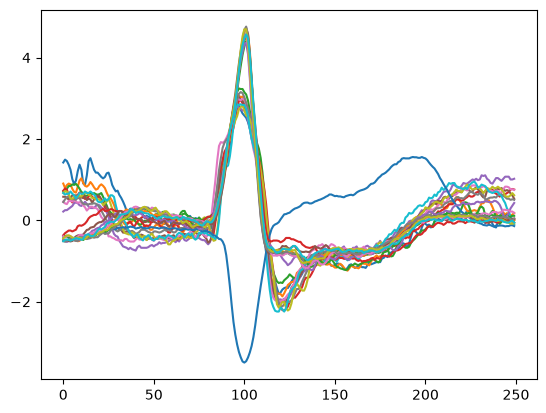

In [12]:
for beat in L[:10]:
    plt.plot(beat)

for beat in V[:10]:
    plt.plot(beat)


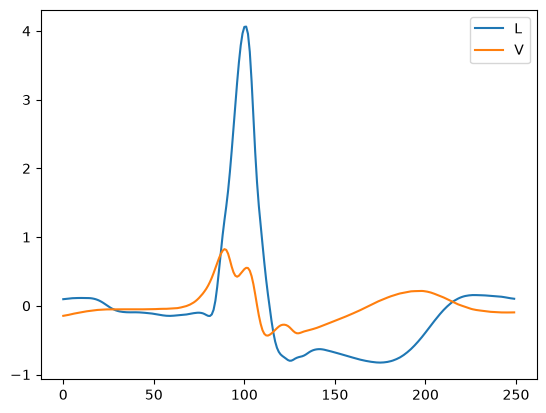

In [13]:
mean_L = L.mean(axis=0)
mean_V = V.mean(axis=0)

plt.plot(mean_L, label="L")
plt.plot(mean_V, label="V")
plt.legend()

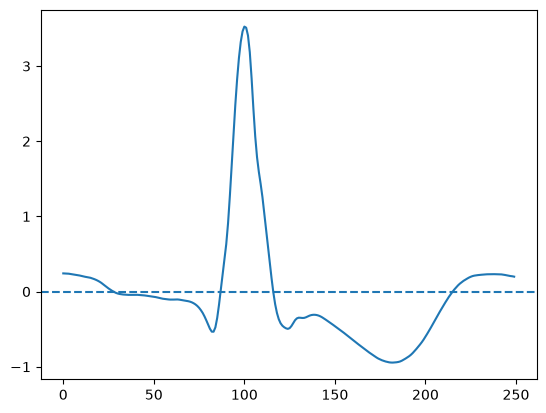

In [14]:
plt.plot(mean_L - mean_V)
plt.axhline(0, linestyle="--")

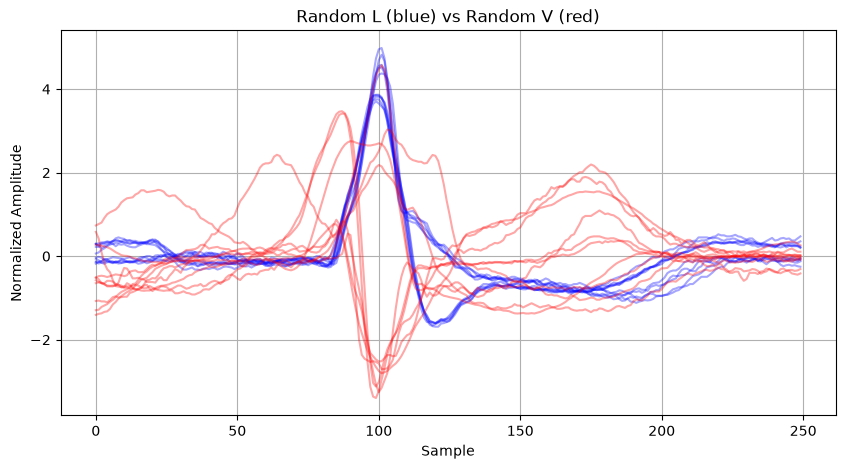

In [15]:
plt.figure(figsize=(10,5))

l_idx = np.random.choice(len(L), 10, replace=False)
v_idx = np.random.choice(len(V), 10, replace=False)

for i in l_idx:
    plt.plot(L[i], color="blue", alpha=0.35)

for i in v_idx:
    plt.plot(V[i], color="red", alpha=0.35)

plt.title("Random L (blue) vs Random V (red)")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.show()

In [16]:
std_L = L.std(axis=0)
std_V = V.std(axis=0)

mean_L = L.mean(axis=0)
mean_V = V.mean(axis=0)

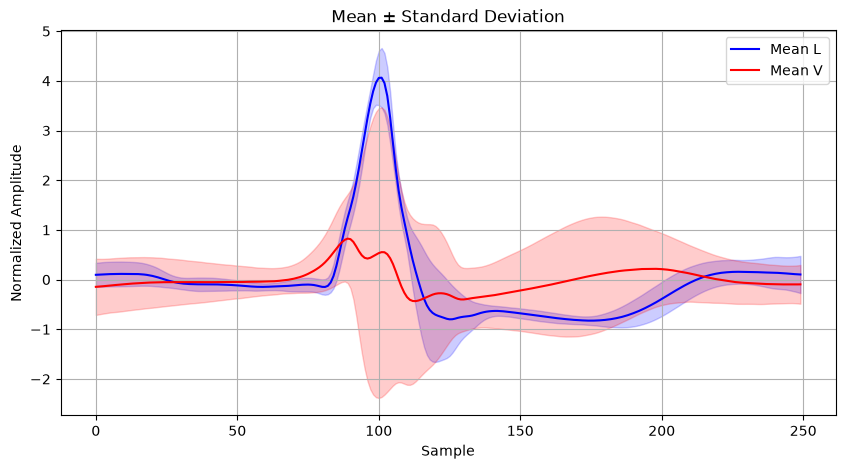

In [17]:
plt.figure(figsize=(10,5))

plt.plot(mean_L, color="blue", label="Mean L")
plt.fill_between(
    range(len(mean_L)),
    mean_L - std_L,
    mean_L + std_L,
    color="blue",
    alpha=0.2,
)

plt.plot(mean_V, color="red", label="Mean V")
plt.fill_between(
    range(len(mean_V)),
    mean_V - std_V,
    mean_V + std_V,
    color="red",
    alpha=0.2,
)

plt.legend()
plt.title("Mean ± Standard Deviation")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.show()